In [1]:
# ============================================================
# NOTEBOOK 05 — MODEL INTERPRETATION
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# ============================================================
# STEP 2 — Load enhanced descriptor dataset
# ============================================================

data_path = Path("../data/enhanced_material_descriptors.csv")

df = pd.read_csv(data_path)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (93902, 26)

Columns:
['num_elements', 'total_atoms', 'mean_atomic_number', 'min_atomic_number', 'max_atomic_number', 'mean_atomic_mass', 'min_atomic_mass', 'max_atomic_mass', 'mean_atomic_radius', 'min_atomic_radius', 'max_atomic_radius', 'crys', 'spg_number', 'mean_electronegativity', 'min_electronegativity', 'max_electronegativity', 'electronegativity_difference', 'mean_ionization_energy', 'mean_electron_affinity', 'mean_s_valence', 'mean_p_valence', 'mean_d_valence', 'mean_f_valence', 'mean_period', 'mean_group', 'target_bandgap']


In [3]:
# ============================================================
# STEP 3 — Descriptor families
# ============================================================

composition_features = [
    "num_elements",
    "total_atoms",
    "mean_atomic_number",
    "min_atomic_number",
    "max_atomic_number",
    "mean_atomic_mass",
    "min_atomic_mass",
    "max_atomic_mass",
    "mean_atomic_radius",
    "min_atomic_radius",
    "max_atomic_radius"
]

electronegativity_features = [
    "mean_electronegativity",
    "min_electronegativity",
    "max_electronegativity",
    "electronegativity_difference"
]

energy_features = [
    "mean_ionization_energy",
    "mean_electron_affinity"
]

valence_features = [
    "mean_s_valence",
    "mean_p_valence",
    "mean_d_valence",
    "mean_f_valence"
]

periodic_features = [
    "mean_period",
    "mean_group"
]

structural_features = [
    "crys",
    "spg_number"
]

print("Descriptor groups defined.")

Descriptor groups defined.


In [4]:
# ============================================================
# STEP 4 — Load final test predictions
# ============================================================

results_path = Path("../results/final_test_predictions.csv")

test_results = pd.read_csv(results_path)

print("Test results shape:", test_results.shape)

print(
    test_results[
        ["actual_bandgap", "predicted_bandgap", "absolute_error"]
    ].head()
)

Test results shape: (18781, 28)
   actual_bandgap  predicted_bandgap  absolute_error
0           0.000           0.000000        0.000000
1           0.000           0.000000        0.000000
2           0.000           0.009025        0.009025
3           0.000           0.000000        0.000000
4           1.658           0.307879        1.350121


In [5]:
# ============================================================
# STEP 5 — Error distribution
# ============================================================

errors = test_results["absolute_error"]

print("Error statistics")
print("-" * 40)
print(f"Mean error   : {errors.mean():.4f} eV")
print(f"Median error : {errors.median():.4f} eV")
print(f"90th percentile: {errors.quantile(0.90):.4f} eV")
print(f"95th percentile: {errors.quantile(0.95):.4f} eV")

Error statistics
----------------------------------------
Mean error   : 0.2381 eV
Median error : 0.0195 eV
90th percentile: 0.7422 eV
95th percentile: 1.1998 eV


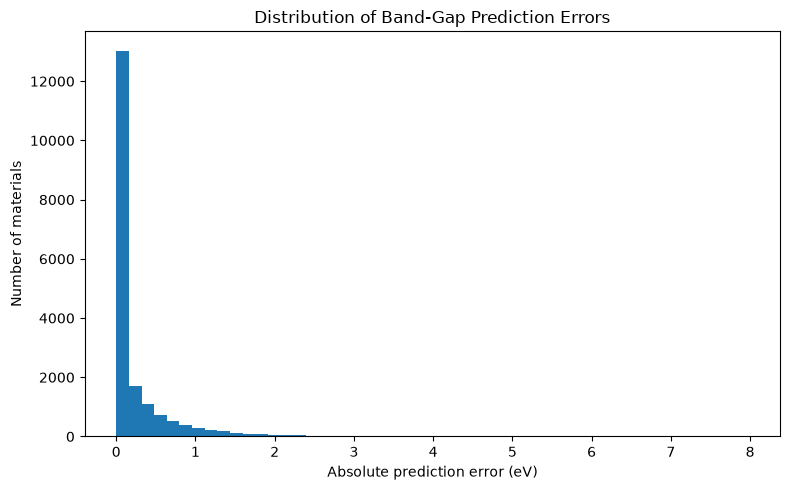

In [6]:
# ============================================================
# STEP 6 — Error distribution plot
# ============================================================

plt.figure(figsize=(8, 5))

plt.hist(
    errors,
    bins=50
)

plt.xlabel("Absolute prediction error (eV)")
plt.ylabel("Number of materials")
plt.title("Distribution of Band-Gap Prediction Errors")

plt.tight_layout()
plt.show()

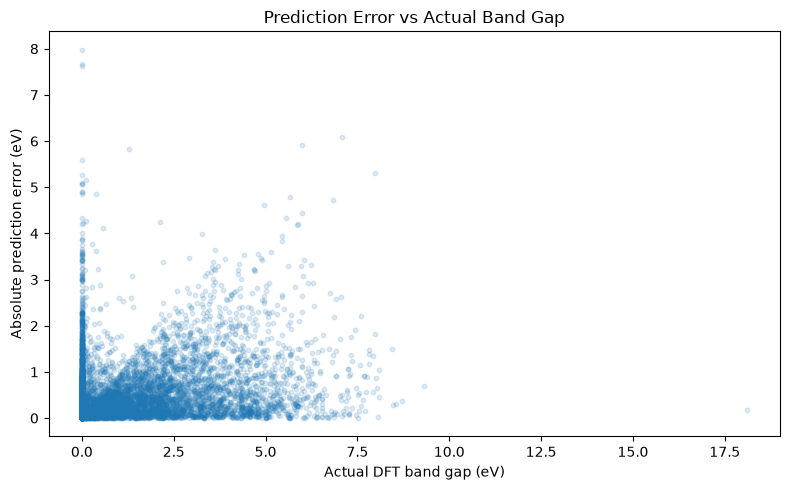

In [7]:
# ============================================================
# STEP 7 — Error vs actual band gap
# ============================================================

plt.figure(figsize=(8, 5))

plt.scatter(
    test_results["actual_bandgap"],
    test_results["absolute_error"],
    alpha=0.15,
    s=10
)

plt.xlabel("Actual DFT band gap (eV)")
plt.ylabel("Absolute prediction error (eV)")
plt.title("Prediction Error vs Actual Band Gap")

plt.tight_layout()
plt.show()

In [8]:
# ============================================================
# STEP 8 — Band-gap error regions
# ============================================================

def gap_region(gap):

    if gap == 0:
        return "0 eV"

    elif gap < 1:
        return "0–1 eV"

    elif gap < 2:
        return "1–2 eV"

    elif gap < 3:
        return "2–3 eV"

    elif gap < 5:
        return "3–5 eV"

    elif gap < 10:
        return "5–10 eV"

    else:
        return ">10 eV"


test_results["gap_region"] = (
    test_results["actual_bandgap"]
    .apply(gap_region)
)

gap_summary = (
    test_results
    .groupby("gap_region", observed=False)
    .agg(
        count=("absolute_error", "size"),
        MAE=("absolute_error", "mean")
    )
)

gap_summary

,count,MAE
gap_region,,
0 eV,13413,0.114771
0–1 eV,1994,0.337954
1–2 eV,1109,0.465549
2–3 eV,850,0.650432
3–5 eV,1031,0.817898
5–10 eV,383,0.904716
>10 eV,1,0.182557


In [9]:
# ============================================================
# STEP 10 — Recreate final model for interpretation
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

feature_columns = [
    "num_elements",
    "total_atoms",
    "mean_atomic_number",
    "min_atomic_number",
    "max_atomic_number",
    "mean_atomic_mass",
    "min_atomic_mass",
    "max_atomic_mass",
    "mean_atomic_radius",
    "min_atomic_radius",
    "max_atomic_radius",
    "mean_electronegativity",
    "min_electronegativity",
    "max_electronegativity",
    "electronegativity_difference",
    "mean_ionization_energy",
    "mean_electron_affinity",
    "mean_s_valence",
    "mean_p_valence",
    "mean_d_valence",
    "mean_f_valence",
    "mean_period",
    "mean_group",
    "crys",
    "spg_number"
]

# Separate X and y
X = df[feature_columns]
y = df["target_bandgap"]

# Same split used earlier
y_class = (y > 0).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y_class
)

numeric_features = [
    col for col in feature_columns
    if col not in ["crys", "spg_number"]
]

categorical_features = [
    "crys",
    "spg_number"
]

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=1.0,
    random_state=42,
    n_jobs=-1
)

interpretation_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", rf)
])

print("Training interpretation model...")

interpretation_pipeline.fit(
    X_train,
    y_train
)

print("Done.")

Training interpretation model...
Done.


In [10]:
# ============================================================
# STEP 11 — Permutation importance
# ============================================================

print("Calculating permutation importance...")

perm = permutation_importance(
    interpretation_pipeline,
    X_test,
    y_test,
    scoring="neg_mean_absolute_error",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance": perm.importances_mean,
    "std": perm.importances_std
})

importance_df = importance_df.sort_values(
    "importance",
    ascending=False
)

importance_df

Calculating permutation importance...


,feature,importance,std
15,mean_ionization_energy,0.282553,0.002126
19,mean_d_valence,0.244844,0.003940
18,mean_p_valence,0.242303,0.002222
22,mean_group,0.114578,0.001306
13,max_electronegativity,0.110624,0.001687
1,total_atoms,0.094639,0.001890
16,mean_electron_affinity,0.079665,0.000573
4,max_atomic_number,0.074105,0.001317
11,mean_electronegativity,0.074049,0.000454
5,mean_atomic_mass,0.061413,0.000543


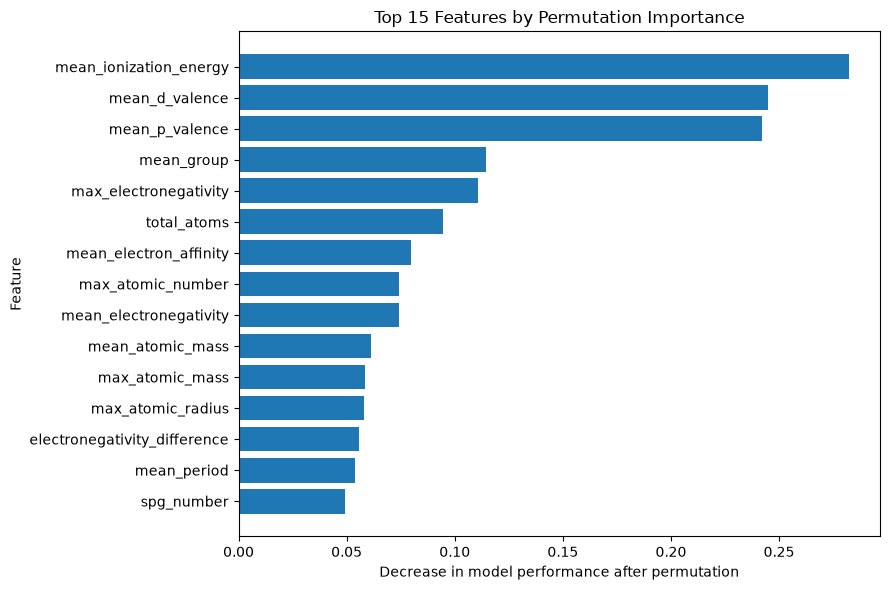

In [11]:
# ============================================================
# STEP 12 — Top feature importance plot
# ============================================================

top_features = importance_df.head(15)

plt.figure(figsize=(9, 6))

plt.barh(
    top_features["feature"][::-1],
    top_features["importance"][::-1]
)

plt.xlabel("Decrease in model performance after permutation")
plt.ylabel("Feature")
plt.title("Top 15 Features by Permutation Importance")

plt.tight_layout()
plt.show()

In [12]:
# ============================================================
# STEP 13 — Save interpretation results
# ============================================================

results_dir = Path("../results")
results_dir.mkdir(parents=True, exist_ok=True)

importance_df.to_csv(
    results_dir / "permutation_feature_importance.csv",
    index=False
)

print("Saved permutation feature importance.")

Saved permutation feature importance.


In [13]:
# ============================================================
# STEP 14 — Descriptor-family importance
# ============================================================

feature_family = {}

for feature in composition_features:
    feature_family[feature] = "Composition"

for feature in electronegativity_features:
    feature_family[feature] = "Electronegativity"

for feature in energy_features:
    feature_family[feature] = "Electronic-energy"

for feature in valence_features:
    feature_family[feature] = "Valence"

for feature in periodic_features:
    feature_family[feature] = "Periodic-table"

for feature in structural_features:
    feature_family[feature] = "Structure"


importance_df["family"] = (
    importance_df["feature"]
    .map(feature_family)
)

family_importance = (
    importance_df
    .groupby("family")["importance"]
    .sum()
    .sort_values(ascending=False)
)

family_importance

family
Valence              0.529028
Composition          0.466041
Electronic-energy    0.362218
Electronegativity    0.282913
Periodic-table       0.168581
Structure            0.066268
Name: importance, dtype: float64

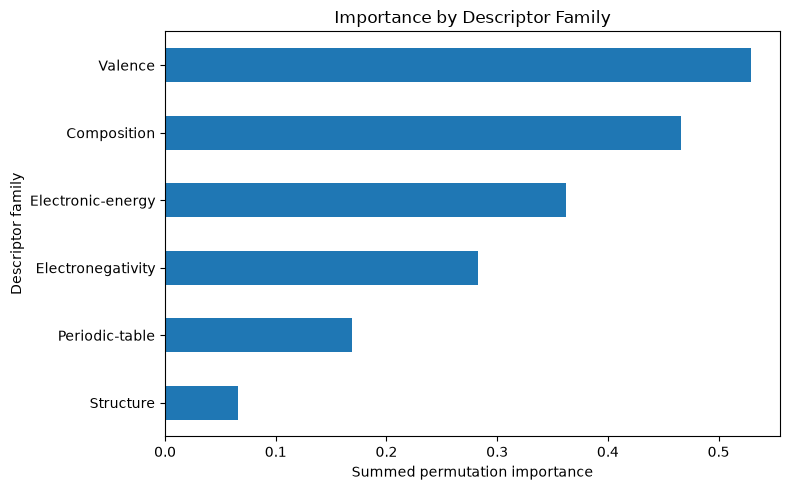

In [14]:
# ============================================================
# STEP 15 — Descriptor-family importance plot
# ============================================================

plt.figure(figsize=(8, 5))

family_importance.sort_values().plot(
    kind="barh"
)

plt.xlabel("Summed permutation importance")
plt.ylabel("Descriptor family")
plt.title("Importance by Descriptor Family")

plt.tight_layout()
plt.show()

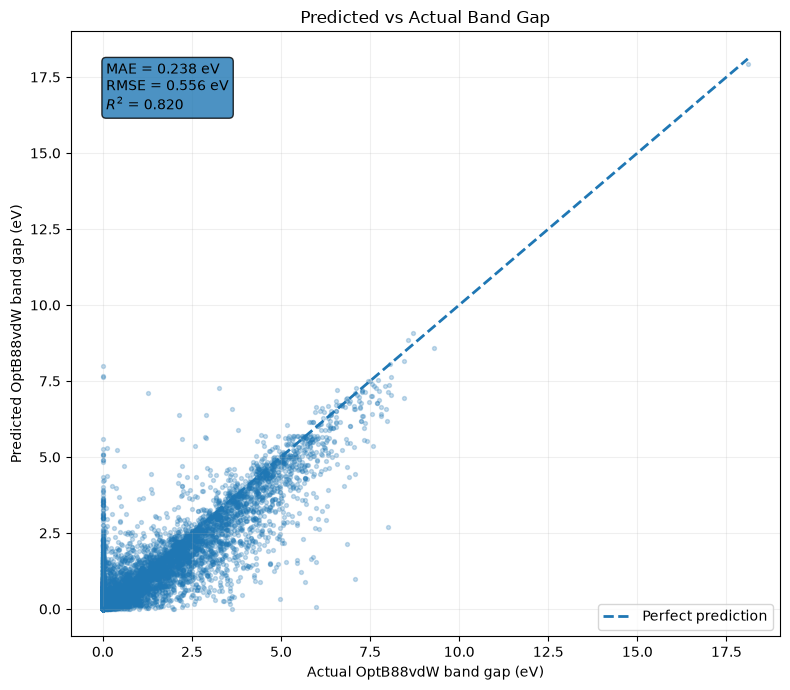

In [1]:
# ============================================================
# FIGURE 1 — Predicted vs Actual Band Gap
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Load final test predictions
test_results = pd.read_csv("../results/final_test_predictions.csv")

actual = test_results["actual_bandgap"]
predicted = test_results["predicted_bandgap"]

# Calculate metrics
mae = np.mean(np.abs(actual - predicted))
rmse = np.sqrt(np.mean((actual - predicted) ** 2))
r2 = 1 - np.sum((actual - predicted) ** 2) / np.sum(
    (actual - actual.mean()) ** 2
)

# Plot
plt.figure(figsize=(8, 7))

plt.scatter(
    actual,
    predicted,
    s=8,
    alpha=0.25
)

# Perfect prediction line
min_value = min(actual.min(), predicted.min())
max_value = max(actual.max(), predicted.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    linewidth=2,
    label="Perfect prediction"
)

plt.xlabel("Actual OptB88vdW band gap (eV)")
plt.ylabel("Predicted OptB88vdW band gap (eV)")

plt.title("Predicted vs Actual Band Gap")

plt.text(
    0.05,
    0.95,
    f"MAE = {mae:.3f} eV\n"
    f"RMSE = {rmse:.3f} eV\n"
    f"$R^2$ = {r2:.3f}",
    transform=plt.gca().transAxes,
    verticalalignment="top",
    bbox=dict(boxstyle="round", alpha=0.8)
)

plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()

# Save
Path("../figures").mkdir(parents=True, exist_ok=True)

plt.savefig(
    "../figures/01_predicted_vs_actual.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

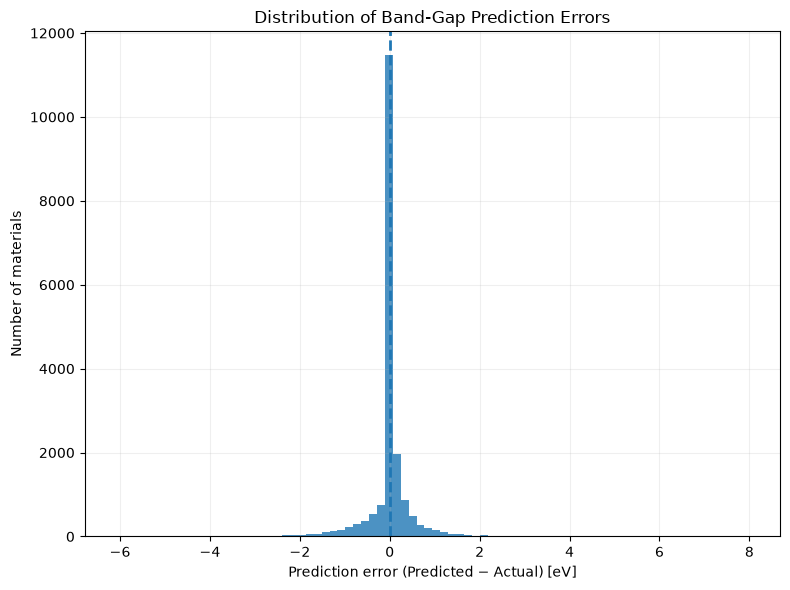

In [2]:
# ============================================================
# FIGURE 2 — Prediction Error Distribution
# ============================================================

errors = predicted - actual

plt.figure(figsize=(8, 6))

plt.hist(
    errors,
    bins=80,
    alpha=0.8
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=2
)

plt.xlabel("Prediction error (Predicted − Actual) [eV]")
plt.ylabel("Number of materials")

plt.title("Distribution of Band-Gap Prediction Errors")

plt.grid(alpha=0.2)
plt.tight_layout()

plt.savefig(
    "../figures/02_error_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

  gap_region  count       MAE
0       0 eV  13413  0.114771
1     0–1 eV   1994  0.337954
2     1–2 eV   1109  0.465549
3     2–3 eV    850  0.650432
4     3–5 eV   1031  0.817898
5    5–10 eV    383  0.904716
6     >10 eV      1  0.182557


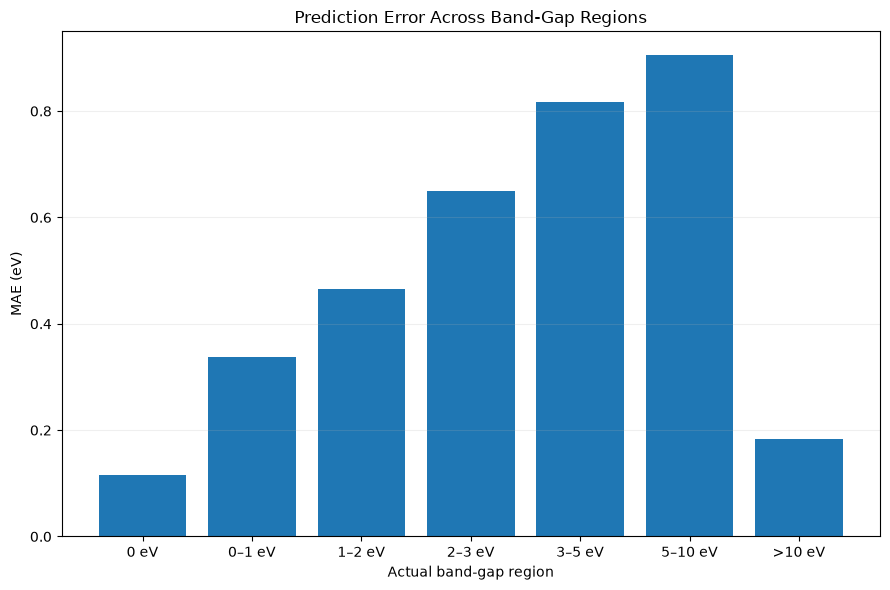

In [3]:
# ============================================================
# FIGURE 3 — MAE by Actual Band-Gap Region
# ============================================================

def gap_region(gap):

    if gap == 0:
        return "0 eV"
    elif gap < 1:
        return "0–1 eV"
    elif gap < 2:
        return "1–2 eV"
    elif gap < 3:
        return "2–3 eV"
    elif gap < 5:
        return "3–5 eV"
    elif gap < 10:
        return "5–10 eV"
    else:
        return ">10 eV"


gap_data = test_results.copy()

gap_data["gap_region"] = gap_data["actual_bandgap"].apply(gap_region)

gap_summary = (
    gap_data
    .groupby("gap_region")
    .agg(
        count=("actual_bandgap", "size"),
        MAE=("absolute_error", "mean")
    )
    .reset_index()
)

order = [
    "0 eV",
    "0–1 eV",
    "1–2 eV",
    "2–3 eV",
    "3–5 eV",
    "5–10 eV",
    ">10 eV"
]

gap_summary["gap_region"] = pd.Categorical(
    gap_summary["gap_region"],
    categories=order,
    ordered=True
)

gap_summary = gap_summary.sort_values("gap_region")

print(gap_summary)

plt.figure(figsize=(9, 6))

plt.bar(
    gap_summary["gap_region"].astype(str),
    gap_summary["MAE"]
)

plt.xlabel("Actual band-gap region")
plt.ylabel("MAE (eV)")
plt.title("Prediction Error Across Band-Gap Regions")

plt.grid(axis="y", alpha=0.2)
plt.tight_layout()

plt.savefig(
    "../figures/03_mae_by_bandgap_region.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

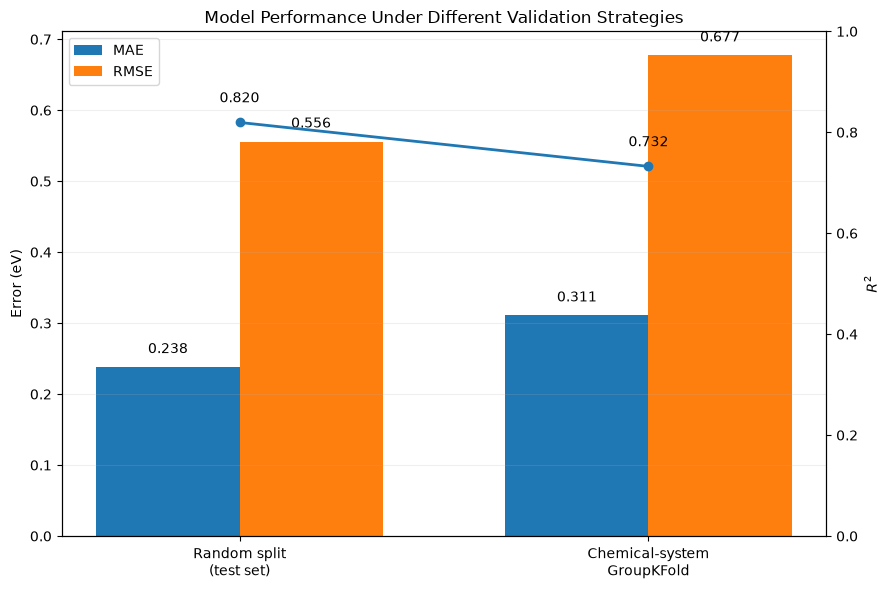

In [4]:
# ============================================================
# FIGURE 4 — Random Split vs Chemical-System GroupKFold
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Results from our completed experiments
evaluation_names = [
    "Random split\n(test set)",
    "Chemical-system\nGroupKFold"
]

mae_values = [
    0.2381,
    0.3109
]

rmse_values = [
    0.5559,
    0.6773
]

r2_values = [
    0.8195,
    0.7324
]

# Create figure
fig, ax1 = plt.subplots(figsize=(9, 6))

x = np.arange(len(evaluation_names))
width = 0.35

# MAE and RMSE
bars1 = ax1.bar(
    x - width/2,
    mae_values,
    width,
    label="MAE"
)

bars2 = ax1.bar(
    x + width/2,
    rmse_values,
    width,
    label="RMSE"
)

ax1.set_ylabel("Error (eV)")
ax1.set_xticks(x)
ax1.set_xticklabels(evaluation_names)
ax1.set_title("Model Performance Under Different Validation Strategies")

ax1.grid(
    axis="y",
    alpha=0.2
)

ax1.legend(
    loc="upper left"
)

# R² on second axis
ax2 = ax1.twinx()

ax2.plot(
    x,
    r2_values,
    marker="o",
    linewidth=2,
    label="$R^2$"
)

ax2.set_ylabel("$R^2$")
ax2.set_ylim(0, 1)

# Add values above bars
for bar in bars1:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.015,
        f"{height:.3f}",
        ha="center",
        va="bottom"
    )

for bar in bars2:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.015,
        f"{height:.3f}",
        ha="center",
        va="bottom"
    )

for i, value in enumerate(r2_values):
    ax2.text(
        x[i],
        value + 0.04,
        f"{value:.3f}",
        ha="center"
    )

plt.tight_layout()

Path("../figures").mkdir(
    parents=True,
    exist_ok=True
)

plt.savefig(
    "../figures/04_validation_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

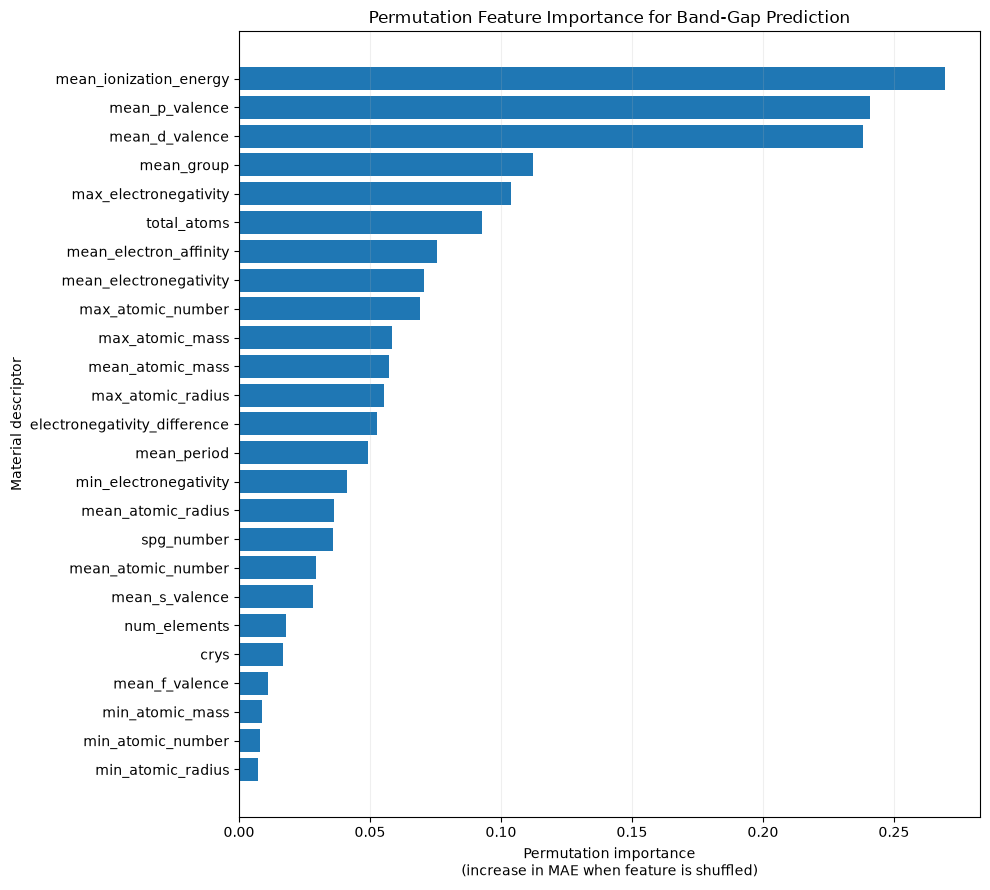

In [5]:
# ============================================================
# FIGURE 5 — Permutation Feature Importance
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Previously calculated permutation importance
importance_data = {
    "feature": [
        "mean_ionization_energy",
        "mean_p_valence",
        "mean_d_valence",
        "mean_group",
        "max_electronegativity",
        "total_atoms",
        "mean_electron_affinity",
        "mean_electronegativity",
        "max_atomic_number",
        "max_atomic_mass",
        "mean_atomic_mass",
        "max_atomic_radius",
        "electronegativity_difference",
        "mean_period",
        "min_electronegativity",
        "mean_atomic_radius",
        "spg_number",
        "mean_atomic_number",
        "mean_s_valence",
        "num_elements",
        "crys",
        "mean_f_valence",
        "min_atomic_mass",
        "min_atomic_number",
        "min_atomic_radius"
    ],

    "importance": [
        0.269390,
        0.240695,
        0.238375,
        0.112222,
        0.103928,
        0.092889,
        0.075575,
        0.070591,
        0.068976,
        0.058458,
        0.057174,
        0.055227,
        0.052816,
        0.049280,
        0.041408,
        0.036120,
        0.035942,
        0.029516,
        0.028313,
        0.018100,
        0.016734,
        0.010957,
        0.008963,
        0.008169,
        0.007114
    ]
}

importance_df = pd.DataFrame(importance_data)

# Sort ascending so largest appears at top
importance_df = importance_df.sort_values(
    "importance",
    ascending=True
)

# Plot
plt.figure(figsize=(10, 9))

plt.barh(
    importance_df["feature"],
    importance_df["importance"]
)

plt.xlabel(
    "Permutation importance\n(increase in MAE when feature is shuffled)"
)

plt.ylabel("Material descriptor")

plt.title(
    "Permutation Feature Importance for Band-Gap Prediction"
)

plt.grid(
    axis="x",
    alpha=0.2
)

plt.tight_layout()

plt.savefig(
    "../figures/05_permutation_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()